In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('medical.csv')
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show
0,2.990000e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,No
1,5.590000e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No
2,4.260000e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,No
3,8.680000e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,No
4,8.840000e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No


In [3]:
df.describe()

,PatientId,AppointmentID,Age,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000
mean,1.474961e+14,5.675305e+06,37.088874,0.321026
std,2.560943e+14,7.129575e+04,23.110205,0.466873
min,3.920000e+04,5.030230e+06,-1.000000,0.000000
25%,4.170000e+12,5.640286e+06,18.000000,0.000000
50%,3.170000e+13,5.680573e+06,37.000000,0.000000
75%,9.440000e+13,5.725524e+06,55.000000,1.000000
max,1.000000e+15,5.790484e+06,115.000000,1.000000


In [4]:
df.describe(include='O') # Object형

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13084\2885228954.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='O') # Object형


,Gender,ScheduledDay,AppointmentDay,Neighbourhood,No-show
count,110527,110527,110527,110527,110527
unique,2,103549,27,81,2
top,F,2016-05-06T07:09:54Z,2016-06-06T00:00:00Z,JARDIM CAMBURI,No
freq,71840,24,4692,7717,88208


In [5]:
# Age가 0이상인 행만 남기자! --> 이상치 제거
df['Age'] >= 0

0         True
1         True
2         True
3         True
4         True
          ... 
110522    True
110523    True
110524    True
110525    True
110526    True
Name: Age, Length: 110527, dtype: bool

In [6]:
df[df['Age'] >= 0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show
0,2.990000e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,No
1,5.590000e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No
2,4.260000e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,No
3,8.680000e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,No
4,8.840000e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No
...,...,...,...,...,...,...,...,...,...
110522,2.570000e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,1,No
110523,3.600000e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,1,No
110524,1.560000e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,1,No
110525,9.210000e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,1,No


In [7]:
df = df[df.Age >= 0]

df.info()

<class 'pandas.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110526 non-null  float64
 1   AppointmentID   110526 non-null  int64  
 2   Gender          110526 non-null  str    
 3   ScheduledDay    110526 non-null  str    
 4   AppointmentDay  110526 non-null  str    
 5   Age             110526 non-null  int64  
 6   Neighbourhood   110526 non-null  str    
 7   SMS_received    110526 non-null  int64  
 8   No-show         110526 non-null  str    
dtypes: float64(1), int64(3), str(5)
memory usage: 14.3 MB


In [8]:
df['No-show'].value_counts() # 값들의 개수(클래스 수)

No-show
No     88207
Yes    22319
Name: count, dtype: int64

In [9]:
# 노쇼 컬럼의 값들을 'Yes / No' --> 1 / 0
df['No-show'] = df['No-show'].map({'Yes':1, 'No':0})
df['No-show'].value_counts()

No-show
0    88207
1    22319
Name: count, dtype: int64

In [10]:
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])

df.info()

<class 'pandas.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110526 non-null  float64            
 1   AppointmentID   110526 non-null  int64              
 2   Gender          110526 non-null  str                
 3   ScheduledDay    110526 non-null  datetime64[us, UTC]
 4   AppointmentDay  110526 non-null  datetime64[us, UTC]
 5   Age             110526 non-null  int64              
 6   Neighbourhood   110526 non-null  str                
 7   SMS_received    110526 non-null  int64              
 8   No-show         110526 non-null  int64              
dtypes: datetime64[us, UTC](2), float64(1), int64(4), str(2)
memory usage: 9.8 MB


In [11]:
# waiting_day = 병원 방문일의 연중 일수 - 예약한 날의 연중 일수
#       예약하고 나서 실제 병원에 가기까지 며칠 기다렸는가?
# dt.dayofyear : 1월 1일을 1로 시작해서 그 해의 몇 번째 날인지 숫자로 반환
df['waiting_day'] = df['AppointmentDay'].dt.dayofyear-df['ScheduledDay'].dt.dayofyear
df.info()

<class 'pandas.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110526 non-null  float64            
 1   AppointmentID   110526 non-null  int64              
 2   Gender          110526 non-null  str                
 3   ScheduledDay    110526 non-null  datetime64[us, UTC]
 4   AppointmentDay  110526 non-null  datetime64[us, UTC]
 5   Age             110526 non-null  int64              
 6   Neighbourhood   110526 non-null  str                
 7   SMS_received    110526 non-null  int64              
 8   No-show         110526 non-null  int64              
 9   waiting_day     110526 non-null  int32              
dtypes: datetime64[us, UTC](2), float64(1), int32(1), int64(4), str(2)
memory usage: 10.2 MB


In [12]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show,waiting_day
0,2.990000e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,0,0
1,5.590000e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0
2,4.260000e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0
3,8.680000e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0
4,8.840000e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0


In [13]:
# waiting_day가 음수라는 것은 "예약일보다 방문일이 더 빠르다"라는 뜻 --> 논리적 오류
#   0이상인 데이터만 남겨서 이상치를 제거
df =df[df['waiting_day'] >= 0]
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show,waiting_day
0,2.990000e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,0,0
1,5.590000e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0
2,4.260000e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0
3,8.680000e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0
4,8.840000e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0
...,...,...,...,...,...,...,...,...,...,...
110522,2.570000e+12,5651768,F,2016-05-03 09:15:35+00:00,2016-06-07 00:00:00+00:00,56,MARIA ORTIZ,1,0,35
110523,3.600000e+12,5650093,F,2016-05-03 07:27:33+00:00,2016-06-07 00:00:00+00:00,51,MARIA ORTIZ,1,0,35
110524,1.560000e+13,5630692,F,2016-04-27 16:03:52+00:00,2016-06-07 00:00:00+00:00,21,MARIA ORTIZ,1,0,41
110525,9.210000e+13,5630323,F,2016-04-27 15:09:23+00:00,2016-06-07 00:00:00+00:00,38,MARIA ORTIZ,1,0,41


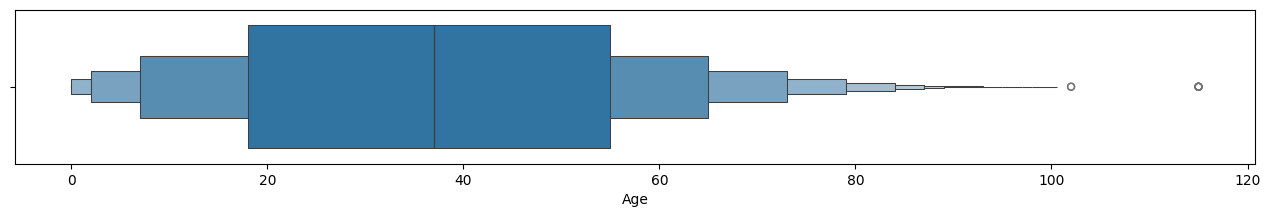

In [14]:
# boxplot으로 이상치 확인
plt.figure(figsize=(16,2))
sns.boxenplot(x=df.Age)
plt.show()

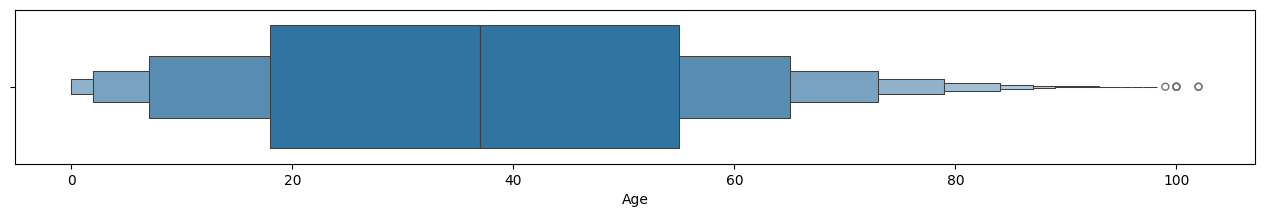

In [15]:
# 110세를 초과하는 나이는 비현실적이라고 판단 --> 제거
df = df[df['Age'] <= 110]

plt.figure(figsize=(16, 2))  # 가로 16인치, 세로 2인치 차트 그릴 도화지 준비
sns.boxenplot(x=df.Age)
plt.show()

In [16]:
# waiting_day == 0 --> 노쇼 비율

# waiting_day == 0 (당일 예약)인 행들 중 'waiting_day' 값 개수 (=> 전체 당일 예약 건수)
# df[df['waiting_day'] == 0] --> 데이터프레임 
a = df[df['waiting_day'] == 0]['waiting_day'].value_counts()

In [17]:
# 앞 조건 + No-show가 발생한 건수 (No-show == 1)
# waiting_day == 0 그리고
# No-show == 1
(df['waiting_day'] == 0) & (df['No-show'] == 1)  # 조건

0         False
1         False
2         False
3         False
4         False
          ...  
110522    False
110523    False
110524    False
110525    False
110526    False
Length: 110454, dtype: bool

In [18]:
cond = (df['waiting_day'] == 0) & (df['No-show'] == 1)  
df[cond]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show,waiting_day
145,2.370000e+13,5639602,M,2016-04-29 09:17:23+00:00,2016-04-29 00:00:00+00:00,17,ITARARÉ,0,1,0
212,4.270000e+14,5642059,M,2016-04-29 14:59:38+00:00,2016-04-29 00:00:00+00:00,62,SANTOS DUMONT,0,1,0
250,2.940000e+14,5640181,M,2016-04-29 10:13:35+00:00,2016-04-29 00:00:00+00:00,0,CARATOÍRA,0,1,0
251,6.540000e+11,5640178,F,2016-04-29 10:13:22+00:00,2016-04-29 00:00:00+00:00,33,CARATOÍRA,0,1,0
440,8.370000e+13,5639495,F,2016-04-29 09:09:55+00:00,2016-04-29 00:00:00+00:00,25,SÃO BENEDITO,0,1,0
...,...,...,...,...,...,...,...,...,...,...
109204,1.520000e+14,5770944,M,2016-06-03 11:11:18+00:00,2016-06-03 00:00:00+00:00,24,CONQUISTA,0,1,0
109603,7.520000e+13,5766961,F,2016-06-02 16:05:46+00:00,2016-06-02 00:00:00+00:00,42,JESUS DE NAZARETH,0,1,0
109856,1.230000e+11,5765114,F,2016-06-02 11:40:06+00:00,2016-06-02 00:00:00+00:00,69,JARDIM DA PENHA,0,1,0
109997,7.990000e+14,5771303,F,2016-06-03 12:17:04+00:00,2016-06-03 00:00:00+00:00,23,GRANDE VITÓRIA,0,1,0


In [ ]:
df[cond]['waiting_day'].value_counts()

waiting_day
0    1792
Name: count, dtype: int64

In [20]:
b = df[cond]['waiting_day'].value_counts()

In [21]:
# b / a : 당일 예약 건수 중에서 실제로 노쇼가 발생한 비율
b / a # 0.046472

waiting_day
0    0.046472
Name: count, dtype: float64

### no_show / show 그룹 나누어서 waiting_day 분포 비교

In [22]:
# 노쇼만 데이터만 따로 모은 데이터프레임
no_show = df[df['No-show'] == 1]

In [ ]:
# 정상 방문인 데이터만 따로 모은 데이터프레임
show = df[df['No-show'] == 0]

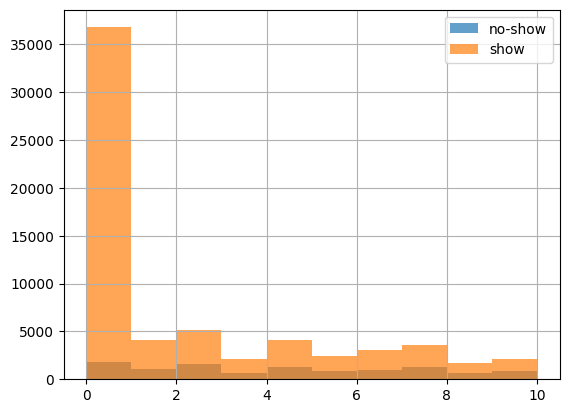

In [26]:
# waiting_day가 10일 이하인 구간만 잘라서 --> 노쇼/정상 방문의 분포 겹쳐서 비교
# alpha : 그래프의 투명도 (0에 가까울수록 투명)
no_show[no_show['waiting_day'] <= 10]['waiting_day'].hist(alpha=0.7, label='no-show')
show[show['waiting_day'] <= 10]['waiting_day'].hist(alpha=0.7, label='show')
plt.legend() # 범례표시
plt.show()

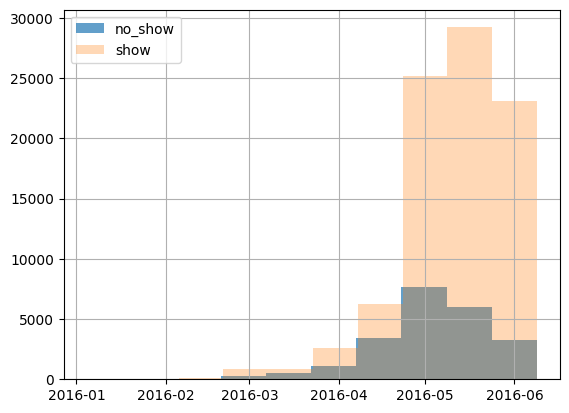

In [27]:
# 예약을 잡은 날짜(ScheduledDay) 기준으로 노쇼/정상 방문 분포 비교
no_show['ScheduledDay'].hist(alpha=0.7, label='no_show')
show['ScheduledDay'].hist(alpha=0.3, label='show')
plt.legend()
plt.show()

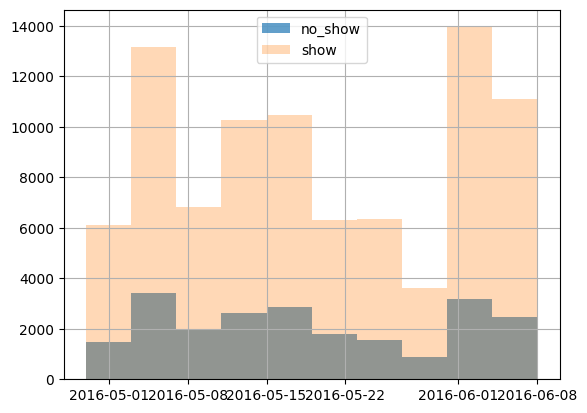

In [28]:
# 실제 병원 방문 예정일 기준으로 노쇼/정상 방문 분포 비교
no_show['AppointmentDay'].hist(alpha=0.7, label='no_show')
show['AppointmentDay'].hist(alpha=0.3, label='show')
plt.legend()
plt.show()

### 환자별 방문 횟수 분석 (재방문 환자)

In [ ]:
# 환자id별로 몇 번 예약했는지 세어서, 예약 횟수가 많은 상위 10명 확인
# .iloc[행 번호, 열 번호]
df.PatientId.value_counts().iloc[0:10] # 행 번호가 처음부터 10번앞까지(0~9), 열 생략

PatientId
8.220000e+14    141
3.350000e+13    127
7.580000e+13    124
8.190000e+13    123
2.690000e+13    117
6.540000e+13    112
6.680000e+13    106
1.450000e+13    104
8.530000e+14    102
8.920000e+13    101
Name: count, dtype: int64

<Axes: >

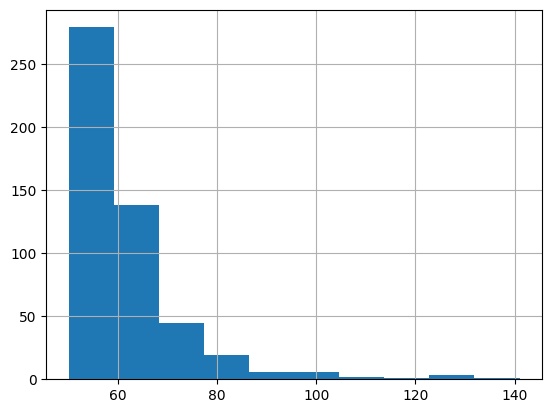

In [30]:
# 상위 500명 환자의 예약 횟수를 히스토그램 (분포 파악 용도)
df.PatientId.value_counts().iloc[0:500].hist()

상위 500명

In [32]:
# waiting_day가 50일 이상이면서 No-show가 1인 환자 중 PatientID별 상위 건수 10명
(df['waiting_day'] >= 50) & (df['No-show'] == 1)
df[(df['waiting_day'] >= 50) & (df['No-show'] == 1)].PatientId.value_counts().iloc[0:10]

PatientId
3.380000e+14    6
7.250000e+13    4
7.850000e+13    4
8.340000e+12    4
8.220000e+14    3
4.970000e+12    3
9.150000e+14    3
5.670000e+12    3
8.460000e+12    3
5.290000e+12    3
Name: count, dtype: int64

In [33]:
a = len(df[(df['SMS_received'] == 0) & (df['No-show'] == 1)])

b = len(df[(df['SMS_received'] == 0) & (df['No-show'] == 0)])

print(f'문자 안받을 때 노쇼 : {a}')
print(f'문자 안받을 때 정상 방문 : {b}')
print(f'문자 안받을 때 노쇼 비율 : {a / (a + b)}')

문자 안받을 때 노쇼 : 12522
문자 안받을 때 정상 방문 : 62494
문자 안받을 때 노쇼 비율 : 0.1669243894635811


In [34]:
c = len(df[(df['SMS_received'] == 1) & (df['No-show'] == 1)])

d = len(df[(df['SMS_received'] == 1) & (df['No-show'] == 0)])

print(f'문자 받을 때 노쇼 : {c}')
print(f'문자 받을 때 정상 방문 : {d}')
print(f'문자 받을 때 노쇼 비율 : {c / (c + d)}')

문자 받을 때 노쇼 : 9770
문자 받을 때 정상 방문 : 25668
문자 받을 때 노쇼 비율 : 0.2756927591850556


In [36]:
# waiting_day, SMS_received, No-show 세 컬럼 간의 상관관계 계산
temp = df[['waiting_day', 'SMS_received', 'No-show']].corr()

<Axes: >

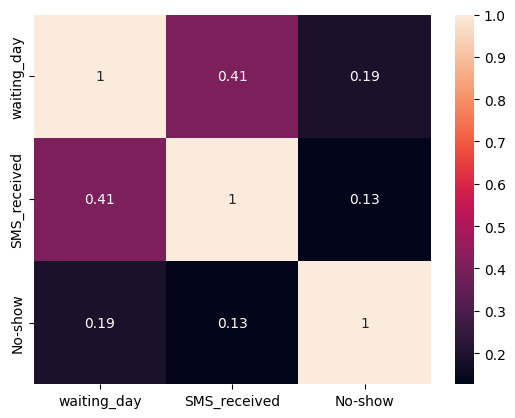

In [38]:
# 상관관계를 색상으로 표현한 히트맵 그래프
sns.heatmap(data=temp, annot=True)

<Axes: xlabel='Gender', ylabel='count'>

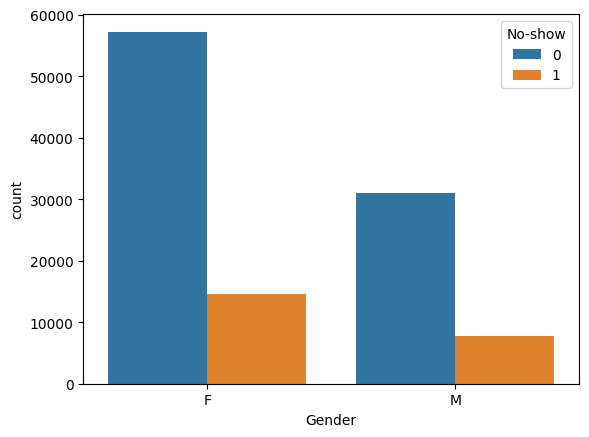

In [39]:
sns.countplot(data=df, x='Gender', hue='No-show')

In [42]:
여성인원수 = df[(df['Gender'] == 'F') & (df['No-show'] == 1)]['Gender'].value_counts()
여성인원수

Gender
F    14577
Name: count, dtype: int64

In [43]:
남성인원수 = df[(df['Gender'] == 'M') & (df['No-show'] == 1)]['Gender'].value_counts()
남성인원수

Gender
M    7715
Name: count, dtype: int64

In [46]:
전체여성수 = df[df['Gender'] == 'F']['Gender'].value_counts()

전체남성수 = df[df['Gender'] == 'M']['Gender'].value_counts()

In [47]:
print(여성인원수 / 전체여성수)
print(남성인원수 / 전체남성수) #  결과가 비슷하다면 "성별은 노쇼에 크게 영향을 주지 않는다!"라는 해석을 내린다.

Gender
F    0.203062
Name: count, dtype: float64
Gender
M    0.199519
Name: count, dtype: float64
